In [11]:
%pip install tqdm pyarrow
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Prep for parallelization and fast running

In [12]:
%%writefile scenario_worker.py
import copy
import numpy as np
from scenario_class import Scenario

# We must put the base params here so the worker file knows about them
base_scenario_params = {
    "end_year": 2100,
    "carbon_budget": 1150 * 0.95 - 2 * 35,
    "gdp_assumption": "constant_ratio",
    "pop_growth_assumption": "semi_log_model",
    "tech_evolution_assumption": "plausible",
    "tech_hysteresis_assumption": "pessimistic_degrowth",
    "steady_state_high_income_assumption": "off",
    "k": 0.05,
    "t0": 2060,
    "population_hysteresis_assumption": "off",
    "run_until_2100": "on",
    "cdr_level_2100": 5,
    "emission_elasticity_assumption": "constant",
}

def run_single_scenario_with_deciles(param_tuple):
    """
    Runs a single iteration of the scenario and returns the extracted trajectory rows.
    """
    inc, cdr, fir, elast = param_tuple
    
    params = copy.deepcopy(base_scenario_params)
    params["income_goal"] = inc
    params["cdr_assumption"] = cdr
    params["final_improvement_rate"] = fir
    params["base_elasticity"] = elast
    
    scenario = Scenario(params)
    scenario.run()
    
    scenario_rows = []
    
    for country_name, country in scenario.countries.items():
        for year in country.gdp_trajectory.keys():
            if year > params["end_year"]:
                continue
            
            pop = country.population_trajectory.get(year, np.nan)
            gdp = country.gdp_trajectory.get(year, np.nan)
            gdppc = country.gdppc_trajectory.get(year, np.nan)
            tot_emissions = country.emissions_trajectory.get(year, np.nan)
            gini = country.gini_coefficient_trajectory.get(year, np.nan)
            
            for d in range(1, 11):
                d_key = f'decile{d}'
                
                decile_income = country.decile_trajectories.get(d_key, {}).get(year, np.nan)
                decile_emissions_pc = country.decile_emissions_trajectories_pc.get(d_key, {}).get(year, np.nan)
                decile_absolute_emissions = country.decile_emissions_trajectories.get(d_key, {}).get(year, np.nan)
                
                row = {
                    "Income_Goal": inc,
                    "CDR_Assumption": cdr,
                    "Final_Improvement_Rate": fir,
                    "Elasticity": elast,
                    "Country": country_name,
                    "Country_Code": getattr(country, 'code', 'UNKNOWN'),
                    "Year": year,
                    "Decile": d,
                    "Decile_Income": decile_income,
                    "Decile_Emissions_pc": decile_emissions_pc,
                    "Decile_Emissions_Absolute": decile_absolute_emissions,
                    "Macro_Population": pop,
                    "Macro_GDP": gdp,
                    "Macro_GDP_pc": gdppc,
                    "Macro_Total_Emissions": tot_emissions,
                    "Gini": gini
                }
                scenario_rows.append(row)
                
    return scenario_rows

Overwriting scenario_worker.py


In [13]:
import itertools
import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm

# THE MAGIC FIX: Import the worker function from the physical file we just created
from scenario_worker import run_single_scenario_with_deciles

if __name__ == '__main__':
    # Grids
    income_goals = list(range(5000, 35000, 5000)) 
    cdr_assumptions = ["off", "on"]
    final_improvement_rates = [-0.03, -0.05, -0.08] 
    elasticities = np.round(np.arange(0.5, 1.6, 0.5), 2) 

    permutations = list(itertools.product(
        income_goals, cdr_assumptions, final_improvement_rates, elasticities
    ))

    total_runs = len(permutations)
    print(f"Total scenario combinations to run: {total_runs}")
    print("Warning: Decile extraction will generate roughly 10x the rows. Expect a large dataset.")

    master_results = []

    # Execute in Parallel
    with ProcessPoolExecutor() as executor:
        futures = {executor.submit(run_single_scenario_with_deciles, p): p for p in permutations}
        
        for future in tqdm(as_completed(futures), total=total_runs, desc="Running Scenarios"):
            try:
                result_rows = future.result()
                master_results.extend(result_rows)
            except Exception as e:
                failed_params = futures[future]
                print(f"Scenario failed for parameters {failed_params}: {e}")

     #print(f"\nFinished running {total_runs} scenarios!")
    print(f"Total rows generated: {len(master_results):,}")

    # Convert to DataFrame and save
    print("Converting to DataFrame...")
    df_master = pd.DataFrame(master_results)

    parquet_filename = "scenario_results_with_deciles.parquet"
    print(f"Saving to {parquet_filename} (Parquet format)...")
    
    try:
        df_master.to_parquet(parquet_filename, index=False)
        print("Done! The file is ready for analysis.")
    except ImportError:
        print("You don't have pyarrow installed. Falling back to CSV...")
        csv_filename = "scenario_results_with_deciles.csv"
        df_master.to_csv(csv_filename, index=False)
        print(f"Done! Saved to {csv_filename}.")

Total scenario combinations to run: 108


Running Scenarios:   0%|          | 0/108 [00:00<?, ?it/s]

Total rows generated: 12,798,000
Converting to DataFrame...
Saving to scenario_results_with_deciles.parquet (Parquet format)...
Done! The file is ready for analysis.


## Elasticity influence on emissions Germany 

<>:97: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:114: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:137: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:145: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:189: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:257: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:271: SyntaxWarning: "\e" is an invalid escape sequence. Such sequenc

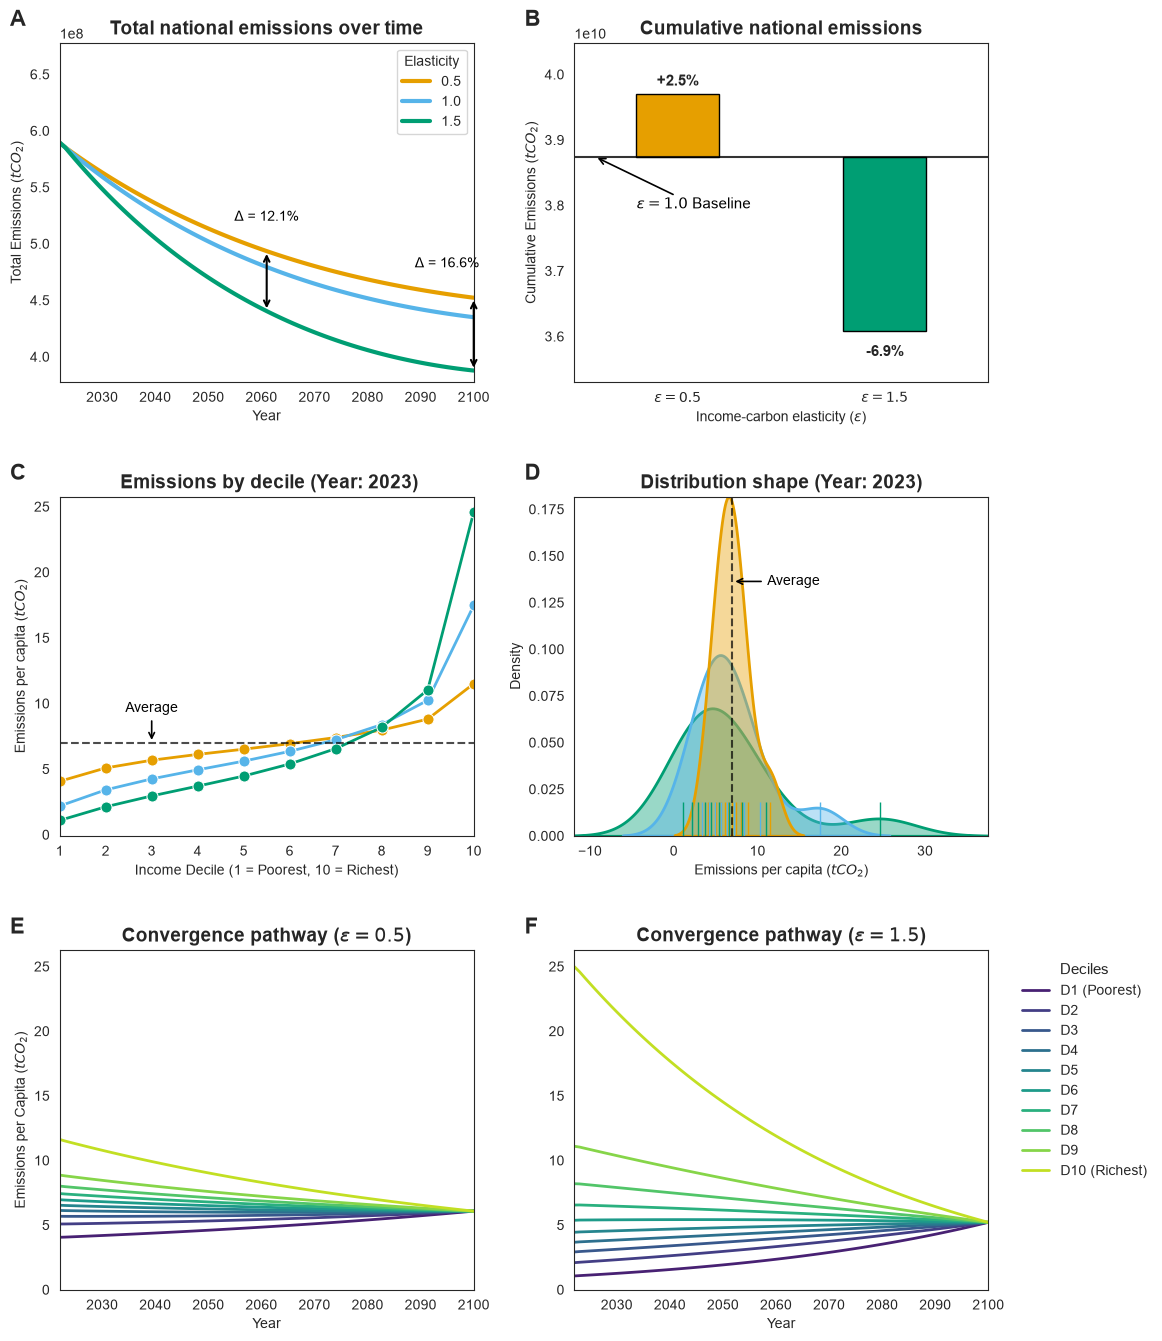

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load Data & Set Target Scenario
# ==========================================
try:
    df = pd.read_parquet("scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("scenario_results_with_deciles.csv")

# Scenario Parameters
target_income = 20000
target_fir = -0.05
target_cdr = "off"
target_country = "Germany"
snapshot_year = 2023 # The almost-initial year

# Isolate the specific scenario
df_scenario = df[
    (df["Income_Goal"] == target_income) & 
    (df["Final_Improvement_Rate"] == target_fir) & 
    (df["CDR_Assumption"] == target_cdr)
].copy()

# Ensure we have a clean string for deciles to sort legends easily
df_scenario["Decile_Label"] = df_scenario["Decile"].apply(
    lambda d: f"D{d} (Poorest)" if d == 1 else (f"D{d} (Richest)" if d == 10 else f"D{d}")
)


# ==============================================================================
# FIGURE 1: The New 6-Panel Mosaic Plot
# ==============================================================================
# Enforce a clean white background
sns.set_style("white")

df_country = df_scenario[df_scenario["Country"] == target_country].copy()
df_macro_country = df_country[['Year', 'Elasticity', 'Macro_Total_Emissions']].drop_duplicates()

# Define the new mosaic layout (3 rows, 2 columns): 
# Row 1: A (Left), B (Right)
# Row 2: C (Left), D (Right)
# Row 3: E (Left), F (Right)
layout = """
AB
CD
EF
"""
# Adjusted figsize to accommodate the new 6-panel grid gracefully
fig, axes = plt.subplot_mosaic(layout, figsize=(12, 14))
fig.patch.set_facecolor('white')

# Colorblind-friendly Okabe-Ito palette
cb_colors = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#F0E442", "#0072B2", "#D55E00", "#000000"]

# Ensure color consistency by manually mapping sorted elasticities
unique_elasticities = sorted(df_macro_country['Elasticity'].unique())
color_dict = {e: cb_colors[i % len(cb_colors)] for i, e in enumerate(unique_elasticities)}

# --- PANEL A: Macro Total Emissions Trajectories ---
sns.lineplot(
    data=df_macro_country, x="Year", y="Macro_Total_Emissions", 
    hue="Elasticity", palette=list(color_dict.values()), linewidth=3, ax=axes['A']
)
axes['A'].set_title("Total national emissions over time", fontsize=14, fontweight='bold')
axes['A'].set_ylabel("Total Emissions ($tCO_2$)")
axes['A'].grid(False) # Gridlines removed
axes['A'].margins(x=0) # 0 margins
axes['A'].text(-0.12, 1.05, "A", transform=axes['A'].transAxes, fontsize=16, fontweight='bold')

# Add per year diff annotation as PERCENTAGE (midway and last year to illustrate magnitude)
years = sorted(df_macro_country['Year'].unique())
if len(years) > 1:
    last_year = years[-1]
    mid_year = years[len(years) // 2]
    
    # Store overall max to add safe padding above the lines
    overall_max = df_macro_country['Macro_Total_Emissions'].max()
    y_padding = overall_max * 0.04 # Standardized padding
    
    # === ANNOTATION 1: Mid Year (Explicitly separated for easy positioning) ===
    y1_data = df_macro_country[df_macro_country['Year'] == mid_year]
    y1_max = y1_data['Macro_Total_Emissions'].max()
    y1_min = y1_data['Macro_Total_Emissions'].min()
    
    pct1_diff = ((y1_max - y1_min) / y1_min) * 100
    # Changed from .2g to .1f to display exact dynamic decimals
    pct1_str = f"{pct1_diff:.1f}"
        
    axes['A'].annotate('', xy=(mid_year, y1_max), xytext=(mid_year, y1_min),
                       arrowprops=dict(arrowstyle='<->', lw=1.5, color='black'))
    
    # You can change 'mid_year' and 'y1_max + y_padding' here to manually shift this specific text
    axes['A'].text(mid_year, y1_max + y_padding, f"$\Delta$ = {pct1_str}%", 
                   va='bottom', ha='center', fontsize=10, color='black')


    # === ANNOTATION 2: Last Year (Explicitly separated for easy positioning) ===
    y2_data = df_macro_country[df_macro_country['Year'] == last_year]
    y2_max = y2_data['Macro_Total_Emissions'].max()
    y2_min = y2_data['Macro_Total_Emissions'].min()
    
    pct2_diff = ((y2_max - y2_min) / y2_min) * 100
    # Changed from .2g to .1f to display exact dynamic decimals
    pct2_str = f"{pct2_diff:.1f}"
        
    axes['A'].annotate('', xy=(last_year, y2_max), xytext=(last_year, y2_min),
                       arrowprops=dict(arrowstyle='<->', lw=1.5, color='black'))
    
    # You can change 'last_year' and 'y2_max + y_padding' here to manually shift this specific text
    axes['A'].text(last_year - 5, y2_max + y_padding, f"$\Delta$ = {pct2_str}%", 
                   va='bottom', ha='center', fontsize=10, color='black')

    # Increase the top y-limit slightly so the new top-placed text isn't cut off
    axes['A'].set_ylim(top=overall_max * 1.15)


# --- PANEL B: Cumulative Emissions Waterfall Chart ---
cum_emissions = df_macro_country.groupby('Elasticity')['Macro_Total_Emissions'].sum().reset_index()

# Attempt to find the elasticity = 1.0 baseline
base_row = cum_emissions[cum_emissions['Elasticity'] == 1.0]
if not base_row.empty:
    base_val = base_row['Macro_Total_Emissions'].values[0]
    # Filter out the baseline so we don't plot its bar
    df_plot = cum_emissions[cum_emissions['Elasticity'] != 1.0].copy()
else:
    # Fallback if exactly 1.0 is missing
    base_val = cum_emissions['Macro_Total_Emissions'].median()
    df_plot = cum_emissions[cum_emissions['Macro_Total_Emissions'] != base_val].copy()

axes['B'].set_title("Cumulative national emissions", fontsize=14, fontweight='bold')
axes['B'].set_ylabel("Cumulative Emissions ($tCO_2$)")
axes['B'].set_xlabel("Income-carbon elasticity ($\epsilon$)")
axes['B'].grid(False) 
axes['B'].text(-0.12, 1.05, "B", transform=axes['B'].transAxes, fontsize=16, fontweight='bold')

# Draw the baseline for Elasticity 1.0
axes['B'].axhline(base_val, color='black', linewidth=1.5, linestyle='-', alpha=0.8)

# Place the baseline text with an offset and arrow pointing to the line to avoid overlapping the bars
axes['B'].annotate('$\epsilon = 1.0$ Baseline', xy=(-0.4, base_val), 
                   xytext=(30, -40), textcoords='offset points',
                   arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                   va='bottom', ha='left', fontsize=11, color='black',
                   bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

# Plot the floating bars (waterfall style)
x_positions = np.arange(len(df_plot))
for idx, (index, row) in enumerate(df_plot.iterrows()):
    e = row['Elasticity']
    val = row['Macro_Total_Emissions']
    delta = val - base_val
    
    # Plot the floating block starting from base_val
    axes['B'].bar(
        x=idx, 
        height=delta, 
        bottom=base_val, 
        color=color_dict[e], 
        edgecolor='black', 
        width=0.4
    )
    
    # Annotate percentage delta
    pct = (delta / base_val) * 100
    sign = "+" if pct > 0 else ""
    # Changed from .2g to .1f to display exact dynamic decimals
    pct_str = f"{sign}{pct:.1f}%"
        
    va = 'bottom' if delta > 0 else 'top'
    offset = abs(delta) * 0.08 if delta != 0 else base_val * 0.01
    y_pos = val + offset if delta > 0 else val - offset
    
    axes['B'].text(
        x=idx, 
        y=y_pos, 
        s=pct_str, 
        ha='center', 
        va=va, 
        fontsize=11, 
        fontweight='bold'
    )

axes['B'].set_xticks(x_positions)
axes['B'].set_xticklabels([f"$\epsilon = {e}$" for e in df_plot['Elasticity']])
axes['B'].set_xlim(-0.5, len(df_plot) - 0.5)

# Adjust y-limits so text is clearly visible above/below the floating blocks
y_min, y_max = axes['B'].get_ylim()
range_y = y_max - y_min
if range_y == 0:
    range_y = base_val * 0.1
axes['B'].set_ylim(y_min - range_y * 0.15, y_max + range_y * 0.15)


# --- PANEL C: Initial Decile Line Plot ---
df_snapshot = df_country[df_country["Year"] == snapshot_year]

# Assert that average emissions are constant across elasticity settings
snapshot_means = df_snapshot.groupby('Elasticity')['Decile_Emissions_pc'].mean()
assert np.allclose(snapshot_means, snapshot_means.iloc[0]), "Average emissions are not constant across elasticities!"
avg_emission = snapshot_means.iloc[0]

sns.lineplot(
    data=df_snapshot, x="Decile", y="Decile_Emissions_pc", hue="Elasticity", 
    palette=list(color_dict.values()), marker="o", markersize=8, linewidth=2, ax=axes['C'], legend=False
)
axes['C'].set_title(f" Emissions by decile (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['C'].set_xlabel("Income Decile (1 = Poorest, 10 = Richest)")
axes['C'].set_ylabel("Emissions per capita ($tCO_2$)")
axes['C'].set_xticks(range(1, 11))
axes['C'].grid(False) # Gridlines removed
axes['C'].margins(x=0) # 0 margins
axes['C'].text(-0.12, 1.05, "C", transform=axes['C'].transAxes, fontsize=16, fontweight='bold')

# Add average line and offset annotation with an arrow
axes['C'].axhline(avg_emission, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
axes['C'].annotate('Average', xy=(3, avg_emission), xytext=(0, 20), textcoords='offset points',
                   arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                   va='bottom', ha='center', fontsize=10, color='black')


# --- PANEL D: KDE Distribution Comparison ---
sns.kdeplot(
    data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
    palette=list(color_dict.values()), fill=True, common_norm=False, alpha=0.4, linewidth=2, ax=axes['D'], legend=False
)
sns.rugplot(
    data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
    palette=list(color_dict.values()), height=0.1, ax=axes['D'], legend=False
)
axes['D'].set_title(f"Distribution shape (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['D'].set_xlabel("Emissions per capita ($tCO_2$)")
axes['D'].set_ylabel("Density")
axes['D'].grid(False) # Gridlines removed
axes['D'].margins(x=0, y=0) # 0 margins
axes['D'].text(-0.12, 1.05, "D", transform=axes['D'].transAxes, fontsize=16, fontweight='bold')

# Add average line and offset annotation with an arrow
axes['D'].axvline(avg_emission, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
axes['D'].annotate('Average', xy=(avg_emission, 0.75), xycoords=('data', 'axes fraction'),
                   xytext=(25, 0), textcoords='offset points',
                   arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                   va='center', ha='left', fontsize=10, color='black')


# --- PANEL E: Decile Emissions Over Time (Elasticity = 0.5) ---
df_elast_low = df_country[df_country["Elasticity"] == 0.5].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_low, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['E'], legend=False
)
axes['E'].set_title("Convergence pathway ($\epsilon = 0.5$)", fontsize=14, fontweight='bold')
axes['E'].set_xlabel("Year")
axes['E'].set_ylabel("Emissions per Capita ($tCO_2$)")
axes['E'].grid(False) # Gridlines removed
axes['E'].margins(x=0) # 0 margins
axes['E'].text(-0.12, 1.05, "E", transform=axes['E'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL F: Decile Emissions Over Time (Elasticity = 1.5) ---
df_elast_high = df_country[df_country["Elasticity"] == 1.5].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_high, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['F']
)
axes['F'].set_title("Convergence pathway ($\epsilon = 1.5$)", fontsize=14, fontweight='bold')
axes['F'].set_xlabel("Year")
axes['F'].set_ylabel("") # Shared visually with E
axes['F'].grid(False) # Gridlines removed
axes['F'].margins(x=0) # 0 margins
axes['F'].text(-0.12, 1.05, "F", transform=axes['F'].transAxes, fontsize=16, fontweight='bold')


# --- Synchronize Y-Axis for Panels E and F ---
max_y_pathway = max(df_elast_low["Decile_Emissions_pc"].max(), df_elast_high["Decile_Emissions_pc"].max())
axes['E'].set_ylim(0, max_y_pathway * 1.05)
axes['F'].set_ylim(0, max_y_pathway * 1.05)

# Clean up legend for Panel F
axes['F'].legend(title="Deciles", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=10, title_fontsize=11)

# Add explicit padding to prevent any overlapping
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=3.0)
plt.subplots_adjust(top=0.94)
plt.show()

<>:100: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:109: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:100: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:109: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/y2/jtf3jgzj36s4hgbp3cmlvy5m0000gn/T/ipykernel_23017/4168328292.py:100: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  axB.set_title("B) Cumulative Emissions: $\Delta$% ($\epsilon=1.5$ vs $1.0$)", fontsize=14, fontweight='bold')
/var/folders/y2/jtf3jgzj36s4hgbp3cmlv

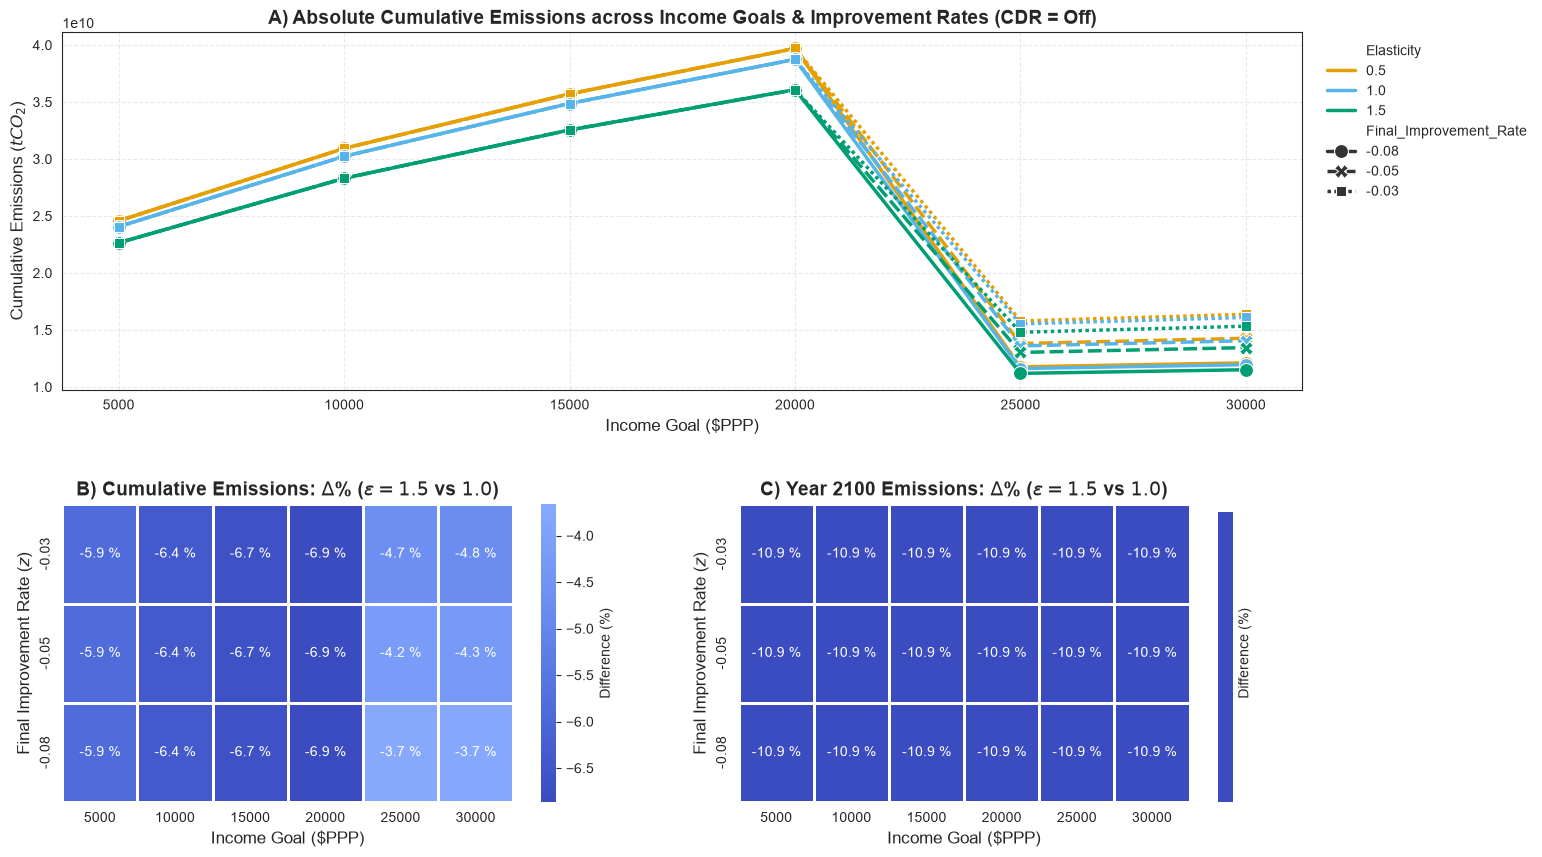

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load Data & Filter for Germany
# ==========================================
try:
    df = pd.read_parquet("scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("scenario_results_with_deciles.csv")

target_country = "Germany"
df_germany = df[df["Country"] == target_country].copy()

# Isolate macro data and drop decile duplicates
df_macro = df_germany[['Income_Goal', 'CDR_Assumption', 'Final_Improvement_Rate', 
                       'Elasticity', 'Year', 'Macro_Total_Emissions']].drop_duplicates()

# ==========================================
# 2. Process Metrics across the Grid
# ==========================================
# Metric 1: Cumulative Emissions
df_cum = df_macro.groupby(
    ['Income_Goal', 'CDR_Assumption', 'Final_Improvement_Rate', 'Elasticity']
)['Macro_Total_Emissions'].sum().reset_index(name='Cumul_Emissions')

# Metric 2: Year 2100 Emissions
df_2100 = df_macro[df_macro['Year'] == df_macro['Year'].max()].groupby(
    ['Income_Goal', 'CDR_Assumption', 'Final_Improvement_Rate', 'Elasticity']
)['Macro_Total_Emissions'].mean().reset_index(name='Emissions_2100')

# Merge metrics
df_metrics = pd.merge(df_cum, df_2100, on=['Income_Goal', 'CDR_Assumption', 'Final_Improvement_Rate', 'Elasticity'])

# Pivot to calculate Percentage Differences (e=1.5 vs e=1.0)
pivot_metrics = df_metrics.pivot(
    index=['Income_Goal', 'CDR_Assumption', 'Final_Improvement_Rate'], 
    columns='Elasticity', 
    values=['Cumul_Emissions', 'Emissions_2100']
).reset_index()

# Flatten MultiIndex columns
pivot_metrics.columns = ['_'.join(map(str, col)).strip('_') for col in pivot_metrics.columns.values]

# Calculate the Delta % (Elasticity 1.5 vs 1.0)
pivot_metrics['Delta_Cumul_Pct'] = ((pivot_metrics['Cumul_Emissions_1.5'] - pivot_metrics['Cumul_Emissions_1.0']) / pivot_metrics['Cumul_Emissions_1.0']) * 100
pivot_metrics['Delta_2100_Pct'] = ((pivot_metrics['Emissions_2100_1.5'] - pivot_metrics['Emissions_2100_1.0']) / pivot_metrics['Emissions_2100_1.0']) * 100

# ==========================================
# 3. Plotting the Summary Dashboard
# ==========================================
sns.set_style("white")
cb_colors = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#F0E442", "#0072B2"]

# We will visualize the CDR="off" scenarios. 
# (You can change this to "on" to see the other half of the grid)
plot_data = df_metrics[df_metrics['CDR_Assumption'] == 'off'].copy()
plot_pivot = pivot_metrics[pivot_metrics['CDR_Assumption'] == 'off'].copy()

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('white')

# Create a GridSpec: Top half spans full width (Panel A), Bottom half is split (Panels B & C)
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1], hspace=0.35, wspace=0.2)
axA = fig.add_subplot(gs[0, :])
axB = fig.add_subplot(gs[1, 0])
axC = fig.add_subplot(gs[1, 1])

# --- PANEL A: Absolute Cumulative Emissions ---
sns.lineplot(
    data=plot_data, 
    x='Income_Goal', y='Cumul_Emissions', 
    hue='Elasticity', style='Final_Improvement_Rate', 
    palette=cb_colors[:len(plot_data['Elasticity'].unique())], 
    markers=True, dashes=True, linewidth=2.5, markersize=10, ax=axA
)
axA.set_title("A) Absolute Cumulative Emissions across Income Goals & Improvement Rates (CDR = Off)", fontsize=14, fontweight='bold')
axA.set_ylabel("Cumulative Emissions ($tCO_2$)", fontsize=12)
axA.set_xlabel("Income Goal ($PPP)", fontsize=12)
axA.grid(True, linestyle="--", alpha=0.4)
axA.margins(x=0.05)

# Fix legend for Panel A
handles, labels = axA.get_legend_handles_labels()
axA.legend(handles=handles, labels=labels, title="", bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)


# --- Prepare Heatmap Matrices ---
# Create 2D grids for heatmaps: Y-axis = FIR, X-axis = Income_Goal
hm_cumul = plot_pivot.pivot(index='Final_Improvement_Rate', columns='Income_Goal', values='Delta_Cumul_Pct').sort_index(ascending=False)
hm_2100 = plot_pivot.pivot(index='Final_Improvement_Rate', columns='Income_Goal', values='Delta_2100_Pct').sort_index(ascending=False)

# --- PANEL B: Cumulative Sensitivity Heatmap ---
sns.heatmap(
    hm_cumul, annot=True, fmt=".1f", cmap="coolwarm", center=0, 
    cbar_kws={'label': 'Difference (%)'}, ax=axB, linewidths=1, linecolor='white'
)
axB.set_title("B) Cumulative Emissions: $\Delta$% ($\epsilon=1.5$ vs $1.0$)", fontsize=14, fontweight='bold')
axB.set_ylabel("Final Improvement Rate ($z$)", fontsize=12)
axB.set_xlabel("Income Goal ($PPP)", fontsize=12)

# --- PANEL C: Year 2100 Sensitivity Heatmap ---
sns.heatmap(
    hm_2100, annot=True, fmt=".1f", cmap="coolwarm", center=0, 
    cbar_kws={'label': 'Difference (%)'}, ax=axC, linewidths=1, linecolor='white'
)
axC.set_title("C) Year 2100 Emissions: $\Delta$% ($\epsilon=1.5$ vs $1.0$)", fontsize=14, fontweight='bold')
axC.set_ylabel("Final Improvement Rate ($z$)", fontsize=12)
axC.set_xlabel("Income Goal ($PPP)", fontsize=12)

# Add % sign to heatmap annotations
for ax in [axB, axC]:
    for t in ax.texts:
        t.set_text(t.get_text() + " %")

plt.show()

In [16]:
import pandas as pd

# Load data (using the same logic as your plot)
try:
    df = pd.read_parquet("scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("scenario_results_with_deciles.csv")

# Same scenario filter
df_scenario = df[
    (df["Income_Goal"] == 15000) & 
    (df["Final_Improvement_Rate"] == -0.05) & 
    (df["CDR_Assumption"] == "off") &
    (df["Country"] == "Germany")
].copy()

# Isolate just the macro data
df_macro = df_scenario[['Year', 'Elasticity', 'Macro_Total_Emissions']].drop_duplicates()

# Pivot the data so we have years as rows and Elasticities as columns
df_pivot = df_macro.pivot(index='Year', columns='Elasticity', values='Macro_Total_Emissions')

# Let's compare the highest and lowest elasticity (assuming 0.5 and 1.5 based on your plots)
e_low = df_pivot.columns.min()
e_high = df_pivot.columns.max()

# 1. Calculate PER YEAR differences
df_pivot['Abs_Diff_Per_Year'] = df_pivot[e_high] - df_pivot[e_low]
df_pivot['Pct_Diff_Per_Year (%)'] = (df_pivot['Abs_Diff_Per_Year'] / df_pivot[e_low]) * 100

# 2. Calculate CUMULATIVE differences
cum_low = df_pivot[e_low].cumsum()
cum_high = df_pivot[e_high].cumsum()

df_pivot['Cumul_Abs_Diff'] = cum_high - cum_low
df_pivot['Cumul_Pct_Diff (%)'] = (df_pivot['Cumul_Abs_Diff'] / cum_low) * 100

# 3. Print a diagnostic summary for every 10 years (and the final year)
years_to_check = list(range(int(df_pivot.index.min()), int(df_pivot.index.max()), 10))
if df_pivot.index.max() not in years_to_check:
    years_to_check.append(df_pivot.index.max())

print(f"--- DIAGNOSTIC CHECK: ELASTICITY {e_high} vs {e_low} ---")
print(f"{'Year':<6} | {'Abs Emission (Low E)':<20} | {'Per-Year % Diff':<15} | {'Cumul % Diff':<15}")
print("-" * 65)

for y in years_to_check:
    if y in df_pivot.index:
        abs_val = df_pivot.loc[y, e_low]
        pct_yr = df_pivot.loc[y, 'Pct_Diff_Per_Year (%)']
        pct_cum = df_pivot.loc[y, 'Cumul_Pct_Diff (%)']
        print(f"{y:<6} | {abs_val:<20.2f} | {pct_yr:>13.2f}% | {pct_cum:>13.2f}%")

--- DIAGNOSTIC CHECK: ELASTICITY 1.5 vs 0.5 ---
Year   | Abs Emission (Low E) | Per-Year % Diff | Cumul % Diff   
-----------------------------------------------------------------
2022   | 589480844.39         |          0.00% |          0.00%
2032   | 537938156.92         |         -3.27% |         -1.49%
2042   | 496421028.10         |         -6.37% |         -3.08%
2052   | 462596461.08         |         -8.92% |         -4.48%
2062   | 435114372.57         |        -10.95% |         -5.69%
2072   | 412919045.05         |        -12.48% |         -6.74%
2082   | 395180521.88         |        -13.53% |         -7.62%
2092   | 381243170.54         |        -14.12% |         -8.37%
2100   | 372476801.28         |        -14.26% |         -8.86%


## Elasticity influence on emissions Nigeria

<>:110: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:124: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:110: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:124: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/y2/jtf3jgzj36s4hgbp3cmlvy5m0000gn/T/ipykernel_23017/1900495722.py:110: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  axes['D'].set_title("Convergence pathway ($\epsilon = 0.5$)", fontsize=14, fontweight='bold')
/var/folders/y2/jtf3jgzj36s4hgbp3cmlvy5m0000gn/T/ipyk

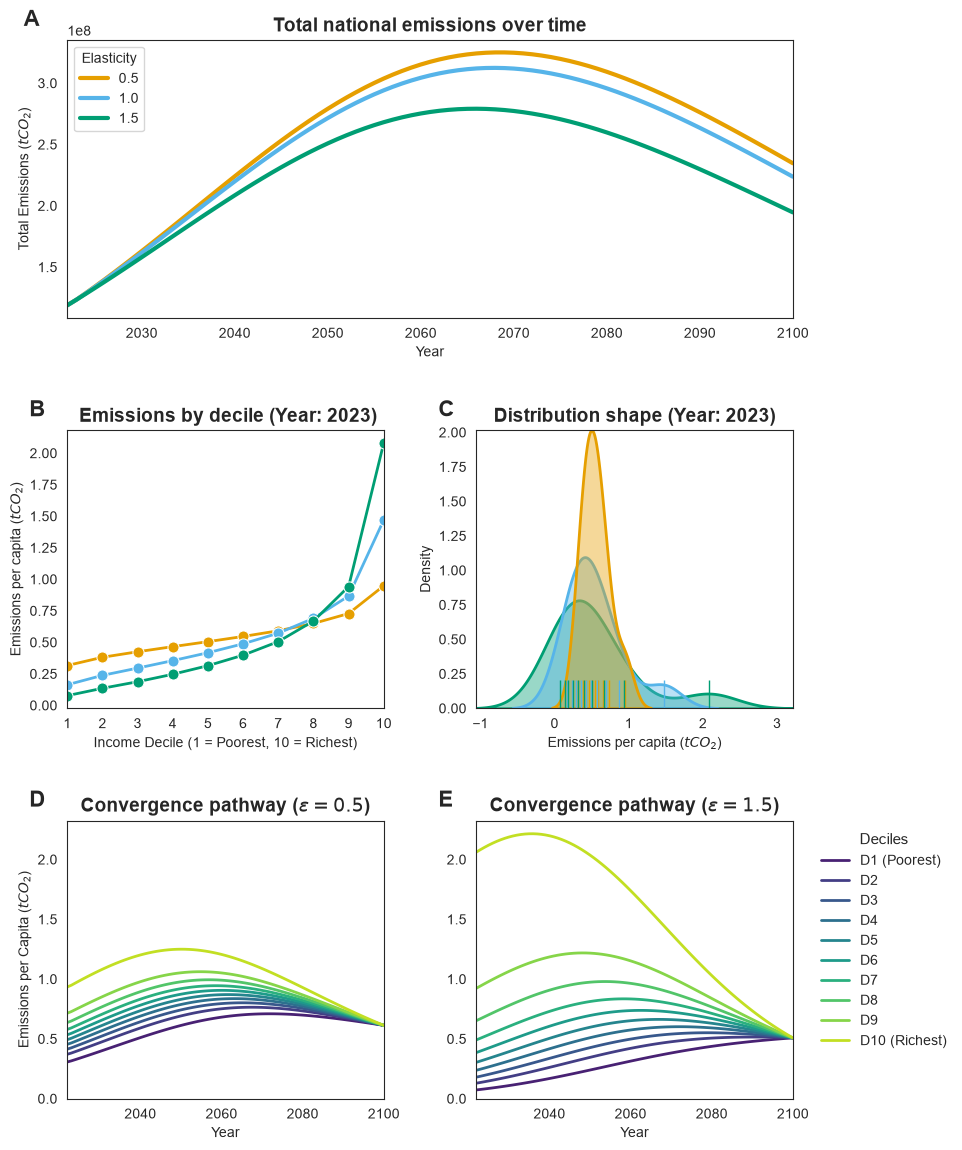

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load Data & Set Target Scenario
# ==========================================
try:
    df = pd.read_parquet("scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("scenario_results_with_deciles.csv")

# Scenario Parameters
target_income = 15000
target_fir = -0.05
target_cdr = "off"
target_country = "Nigeria"
snapshot_year = 2023 # The almost-initial year

# Isolate the specific scenario
df_scenario = df[
    (df["Income_Goal"] == target_income) & 
    (df["Final_Improvement_Rate"] == target_fir) & 
    (df["CDR_Assumption"] == target_cdr)
].copy()

# Ensure we have a clean string for deciles to sort legends easily
df_scenario["Decile_Label"] = df_scenario["Decile"].apply(
    lambda d: f"D{d} (Poorest)" if d == 1 else (f"D{d} (Richest)" if d == 10 else f"D{d}")
)


# ==============================================================================
# FIGURE 1: The New 5-Panel Mosaic Plot
# ==============================================================================
# Enforce a clean white background
sns.set_style("white")

df_country = df_scenario[df_scenario["Country"] == target_country].copy()
df_macro_country = df_country[['Year', 'Elasticity', 'Macro_Total_Emissions']].drop_duplicates()

# Define the new mosaic layout: 
# Row 1: A (Full width)
# Row 2: B (Left), C (Right)
# Row 3: D (Left), E (Right)
layout = """
AA
BC
DE
"""
# Slightly smaller figsize so fonts appear relatively larger
fig, axes = plt.subplot_mosaic(layout, figsize=(10, 12))
fig.patch.set_facecolor('white')

# Colorblind-friendly Okabe-Ito palette for the first three panels
cb_colors = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#F0E442", "#0072B2", "#D55E00", "#000000"]

# --- PANEL A: Macro Total Emissions ---
sns.lineplot(
    data=df_macro_country, x="Year", y="Macro_Total_Emissions", 
    hue="Elasticity", palette=cb_colors, linewidth=3, ax=axes['A']
)
axes['A'].set_title("Total national emissions over time", fontsize=14, fontweight='bold')
axes['A'].set_ylabel("Total Emissions ($tCO_2$)")
axes['A'].grid(False) # Gridlines removed
axes['A'].margins(x=0) # 0 margins
axes['A'].text(-0.06, 1.05, "A", transform=axes['A'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL B: Initial Decile Line Plot ---
df_snapshot = df_country[df_country["Year"] == snapshot_year]

sns.lineplot(
    data=df_snapshot, x="Decile", y="Decile_Emissions_pc", hue="Elasticity", 
    palette=cb_colors, marker="o", markersize=8, linewidth=2, ax=axes['B'], legend=False
)
axes['B'].set_title(f" Emissions by decile (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['B'].set_xlabel("Income Decile (1 = Poorest, 10 = Richest)")
axes['B'].set_ylabel("Emissions per capita ($tCO_2$)")
axes['B'].set_xticks(range(1, 11))
axes['B'].grid(False) # Gridlines removed
axes['B'].margins(x=0) # 0 margins
axes['B'].text(-0.12, 1.05, "B", transform=axes['B'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL C: KDE Distribution Comparison ---
sns.kdeplot(
    data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
    palette=cb_colors, fill=True, common_norm=False, alpha=0.4, linewidth=2, ax=axes['C'], legend=False
)
sns.rugplot(
    data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
    palette=cb_colors, height=0.1, ax=axes['C'], legend=False
)
axes['C'].set_title(f"Distribution shape (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['C'].set_xlabel("Emissions per capita ($tCO_2$)")
axes['C'].set_ylabel("Density")
axes['C'].grid(False) # Gridlines removed
axes['C'].margins(x=0, y=0) # 0 margins
axes['C'].text(-0.12, 1.05, "C", transform=axes['C'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL D: Decile Emissions Over Time (Elasticity = 0.5) ---
df_elast_low = df_country[df_country["Elasticity"] == 0.5].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_low, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['D'], legend=False
)
axes['D'].set_title("Convergence pathway ($\epsilon = 0.5$)", fontsize=14, fontweight='bold')
axes['D'].set_xlabel("Year")
axes['D'].set_ylabel("Emissions per Capita ($tCO_2$)")
axes['D'].grid(False) # Gridlines removed
axes['D'].margins(x=0) # 0 margins
axes['D'].text(-0.12, 1.05, "D", transform=axes['D'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL E: Decile Emissions Over Time (Elasticity = 1.5) ---
df_elast_high = df_country[df_country["Elasticity"] == 1.5].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_high, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['E']
)
axes['E'].set_title("Convergence pathway ($\epsilon = 1.5$)", fontsize=14, fontweight='bold')
axes['E'].set_xlabel("Year")
axes['E'].set_ylabel("") # Shared visually with D
axes['E'].grid(False) # Gridlines removed
axes['E'].margins(x=0) # 0 margins
axes['E'].text(-0.12, 1.05, "E", transform=axes['E'].transAxes, fontsize=16, fontweight='bold')


# --- Synchronize Y-Axis for Panels D and E ---
max_y = max(df_elast_low["Decile_Emissions_pc"].max(), df_elast_high["Decile_Emissions_pc"].max())
axes['D'].set_ylim(0, max_y * 1.05)
axes['E'].set_ylim(0, max_y * 1.05)

# Clean up legend for Panel E
axes['E'].legend(title="Deciles", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=10, title_fontsize=11)

# Add explicit padding to prevent any overlapping
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=3.0)
plt.subplots_adjust(top=0.94)
plt.show()

## Elasticity influence on emissions China

<>:110: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:124: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:110: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:124: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/y2/jtf3jgzj36s4hgbp3cmlvy5m0000gn/T/ipykernel_23017/1772276650.py:110: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  axes['D'].set_title("Convergence pathway ($\epsilon = 0.5$)", fontsize=14, fontweight='bold')
/var/folders/y2/jtf3jgzj36s4hgbp3cmlvy5m0000gn/T/ipyk

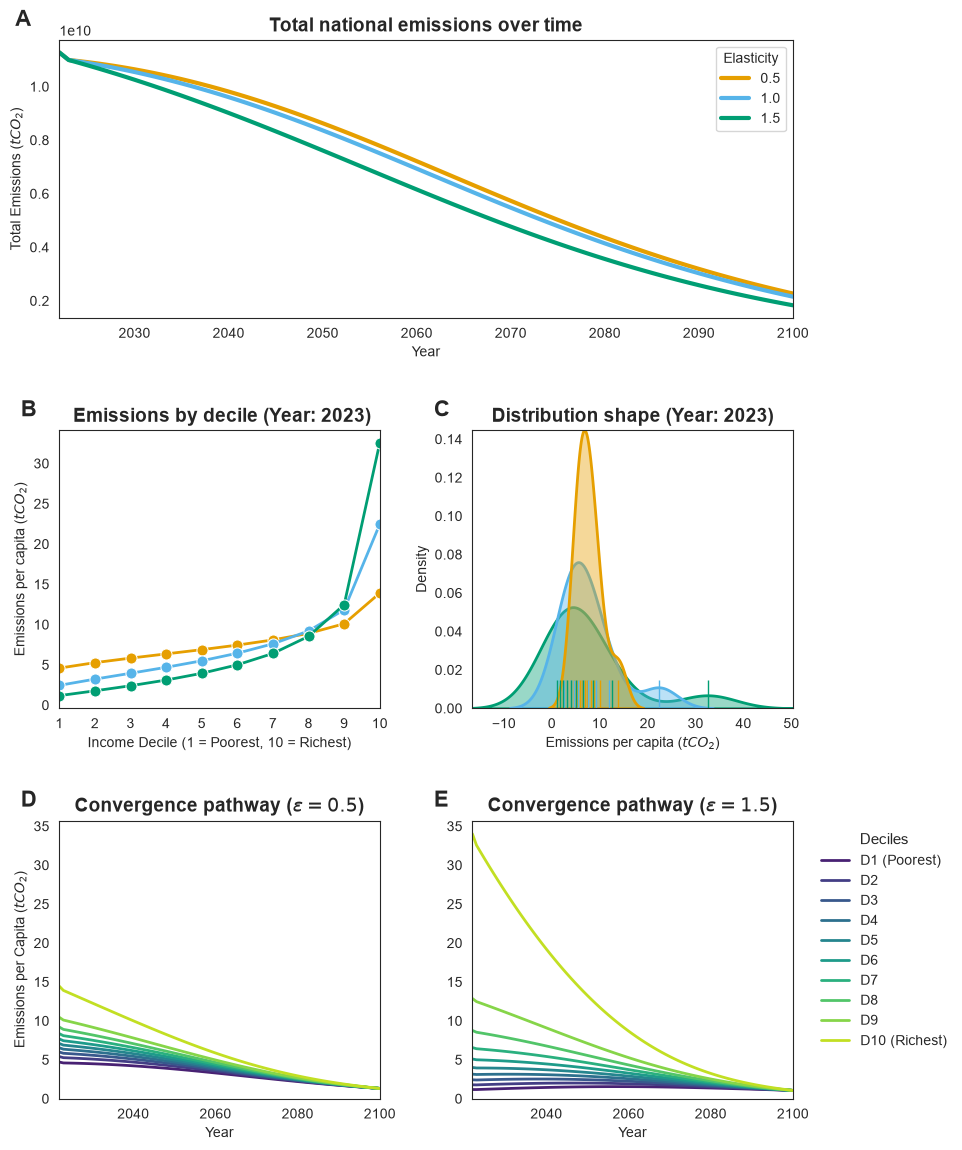

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load Data & Set Target Scenario
# ==========================================
try:
    df = pd.read_parquet("scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("scenario_results_with_deciles.csv")

# Scenario Parameters
target_income = 15000
target_fir = -0.05
target_cdr = "off"
target_country = "China"
snapshot_year = 2023 # The almost-initial year

# Isolate the specific scenario
df_scenario = df[
    (df["Income_Goal"] == target_income) & 
    (df["Final_Improvement_Rate"] == target_fir) & 
    (df["CDR_Assumption"] == target_cdr)
].copy()

# Ensure we have a clean string for deciles to sort legends easily
df_scenario["Decile_Label"] = df_scenario["Decile"].apply(
    lambda d: f"D{d} (Poorest)" if d == 1 else (f"D{d} (Richest)" if d == 10 else f"D{d}")
)


# ==============================================================================
# FIGURE 1: The New 5-Panel Mosaic Plot
# ==============================================================================
# Enforce a clean white background
sns.set_style("white")

df_country = df_scenario[df_scenario["Country"] == target_country].copy()
df_macro_country = df_country[['Year', 'Elasticity', 'Macro_Total_Emissions']].drop_duplicates()

# Define the new mosaic layout: 
# Row 1: A (Full width)
# Row 2: B (Left), C (Right)
# Row 3: D (Left), E (Right)
layout = """
AA
BC
DE
"""
# Slightly smaller figsize so fonts appear relatively larger
fig, axes = plt.subplot_mosaic(layout, figsize=(10, 12))
fig.patch.set_facecolor('white')

# Colorblind-friendly Okabe-Ito palette for the first three panels
cb_colors = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#F0E442", "#0072B2", "#D55E00", "#000000"]

# --- PANEL A: Macro Total Emissions ---
sns.lineplot(
    data=df_macro_country, x="Year", y="Macro_Total_Emissions", 
    hue="Elasticity", palette=cb_colors, linewidth=3, ax=axes['A']
)
axes['A'].set_title("Total national emissions over time", fontsize=14, fontweight='bold')
axes['A'].set_ylabel("Total Emissions ($tCO_2$)")
axes['A'].grid(False) # Gridlines removed
axes['A'].margins(x=0) # 0 margins
axes['A'].text(-0.06, 1.05, "A", transform=axes['A'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL B: Initial Decile Line Plot ---
df_snapshot = df_country[df_country["Year"] == snapshot_year]

sns.lineplot(
    data=df_snapshot, x="Decile", y="Decile_Emissions_pc", hue="Elasticity", 
    palette=cb_colors, marker="o", markersize=8, linewidth=2, ax=axes['B'], legend=False
)
axes['B'].set_title(f" Emissions by decile (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['B'].set_xlabel("Income Decile (1 = Poorest, 10 = Richest)")
axes['B'].set_ylabel("Emissions per capita ($tCO_2$)")
axes['B'].set_xticks(range(1, 11))
axes['B'].grid(False) # Gridlines removed
axes['B'].margins(x=0) # 0 margins
axes['B'].text(-0.12, 1.05, "B", transform=axes['B'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL C: KDE Distribution Comparison ---
sns.kdeplot(
    data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
    palette=cb_colors, fill=True, common_norm=False, alpha=0.4, linewidth=2, ax=axes['C'], legend=False
)
sns.rugplot(
    data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
    palette=cb_colors, height=0.1, ax=axes['C'], legend=False
)
axes['C'].set_title(f"Distribution shape (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['C'].set_xlabel("Emissions per capita ($tCO_2$)")
axes['C'].set_ylabel("Density")
axes['C'].grid(False) # Gridlines removed
axes['C'].margins(x=0, y=0) # 0 margins
axes['C'].text(-0.12, 1.05, "C", transform=axes['C'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL D: Decile Emissions Over Time (Elasticity = 0.5) ---
df_elast_low = df_country[df_country["Elasticity"] == 0.5].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_low, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['D'], legend=False
)
axes['D'].set_title("Convergence pathway ($\epsilon = 0.5$)", fontsize=14, fontweight='bold')
axes['D'].set_xlabel("Year")
axes['D'].set_ylabel("Emissions per Capita ($tCO_2$)")
axes['D'].grid(False) # Gridlines removed
axes['D'].margins(x=0) # 0 margins
axes['D'].text(-0.12, 1.05, "D", transform=axes['D'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL E: Decile Emissions Over Time (Elasticity = 1.5) ---
df_elast_high = df_country[df_country["Elasticity"] == 1.5].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_high, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['E']
)
axes['E'].set_title("Convergence pathway ($\epsilon = 1.5$)", fontsize=14, fontweight='bold')
axes['E'].set_xlabel("Year")
axes['E'].set_ylabel("") # Shared visually with D
axes['E'].grid(False) # Gridlines removed
axes['E'].margins(x=0) # 0 margins
axes['E'].text(-0.12, 1.05, "E", transform=axes['E'].transAxes, fontsize=16, fontweight='bold')


# --- Synchronize Y-Axis for Panels D and E ---
max_y = max(df_elast_low["Decile_Emissions_pc"].max(), df_elast_high["Decile_Emissions_pc"].max())
axes['D'].set_ylim(0, max_y * 1.05)
axes['E'].set_ylim(0, max_y * 1.05)

# Clean up legend for Panel E
axes['E'].legend(title="Deciles", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=10, title_fontsize=11)

# Add explicit padding to prevent any overlapping
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=3.0)
plt.subplots_adjust(top=0.94)
plt.show()

<>:62: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:62: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/y2/jtf3jgzj36s4hgbp3cmlvy5m0000gn/T/ipykernel_23017/2867997668.py:62: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  ax.legend(title="Elasticity ($\epsilon$)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)


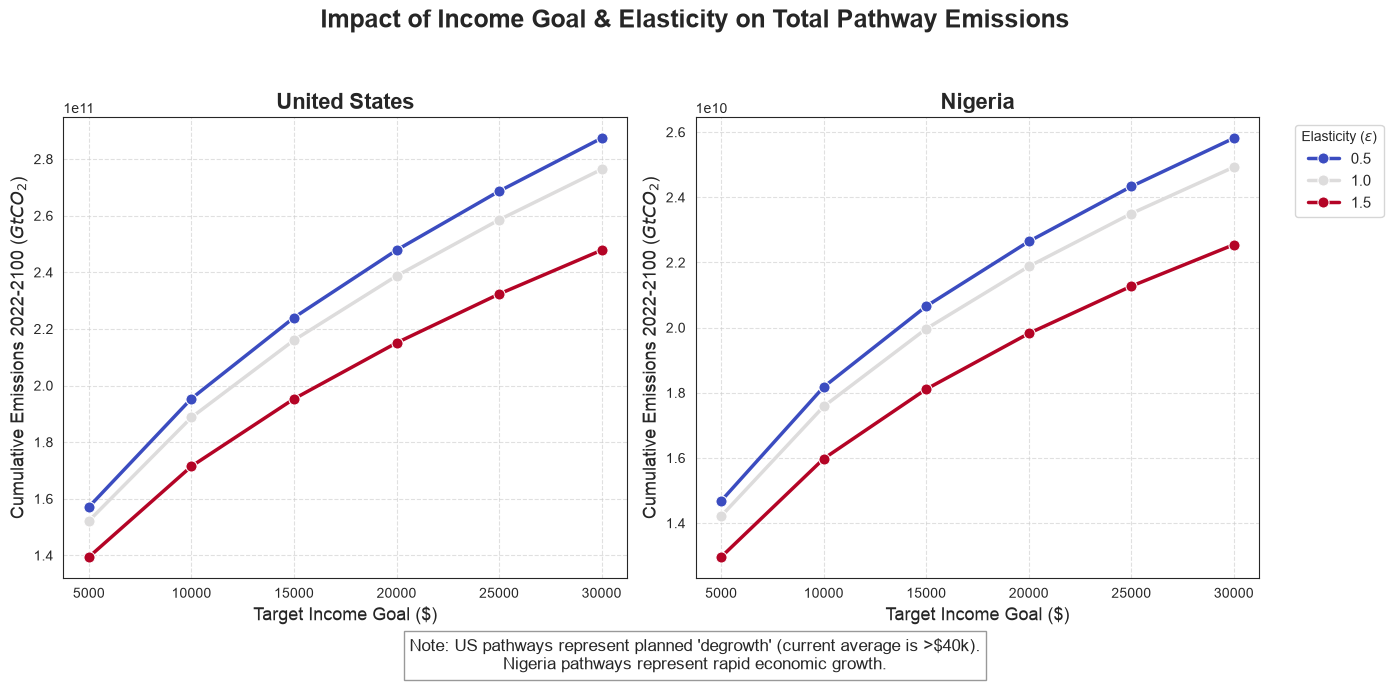

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load Data 
# ==========================================
try:
    df = pd.read_parquet("scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("scenario_results_with_deciles.csv")

# ==========================================
# 2. Filter & Prepare the Data
# ==========================================
target_fir = -0.05
target_cdr = "off"
target_countries = ["United States", "Nigeria"]

# 1. Isolate the macro data to avoid the 10x decile duplication
df_macro = df[
    (df["Country"].isin(target_countries)) & 
    (df["Final_Improvement_Rate"] == target_fir) & 
    (df["CDR_Assumption"] == target_cdr)
][['Country', 'Year', 'Income_Goal', 'Elasticity', 'Macro_Total_Emissions']].drop_duplicates()

# 2. Calculate Cumulative Pathway Emissions (Sum over 2022-2100)
df_cumulative = df_macro.groupby(
    ['Country', 'Income_Goal', 'Elasticity']
)['Macro_Total_Emissions'].sum().reset_index()

# ==========================================
# 3. Create the Side-by-Side Plot
# ==========================================
# sharey=False is important because US absolute emissions are vastly higher than Nigeria's
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for idx, country in enumerate(target_countries):
    ax = axes[idx]
    country_data = df_cumulative[df_cumulative["Country"] == country]
    
    sns.lineplot(
        data=country_data, 
        x="Income_Goal", 
        y="Macro_Total_Emissions", 
        hue="Elasticity", 
        palette="coolwarm", 
        marker="o", # Adds dots at each 5000-step income goal
        markersize=8,
        linewidth=2.5, 
        ax=ax
    )
    
    ax.set_title(f"{country}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Target Income Goal ($)", fontsize=13)
    ax.set_ylabel("Cumulative Emissions 2022-2100 ($GtCO_2$)", fontsize=13)
    ax.grid(True, linestyle="--", alpha=0.6)
    
    # Format the legend beautifully
    if idx == 1:
        ax.legend(title="Elasticity ($\epsilon$)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    else:
        ax.get_legend().remove() # Only need one legend for the whole figure

plt.suptitle("Impact of Income Goal & Elasticity on Total Pathway Emissions", fontsize=18, fontweight='bold', y=1.05)

# Add an explanatory box
plt.figtext(0.5, -0.05, 
            "Note: US pathways represent planned 'degrowth' (current average is >$40k).\n"
            "Nigeria pathways represent rapid economic growth.", 
            ha="center", fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

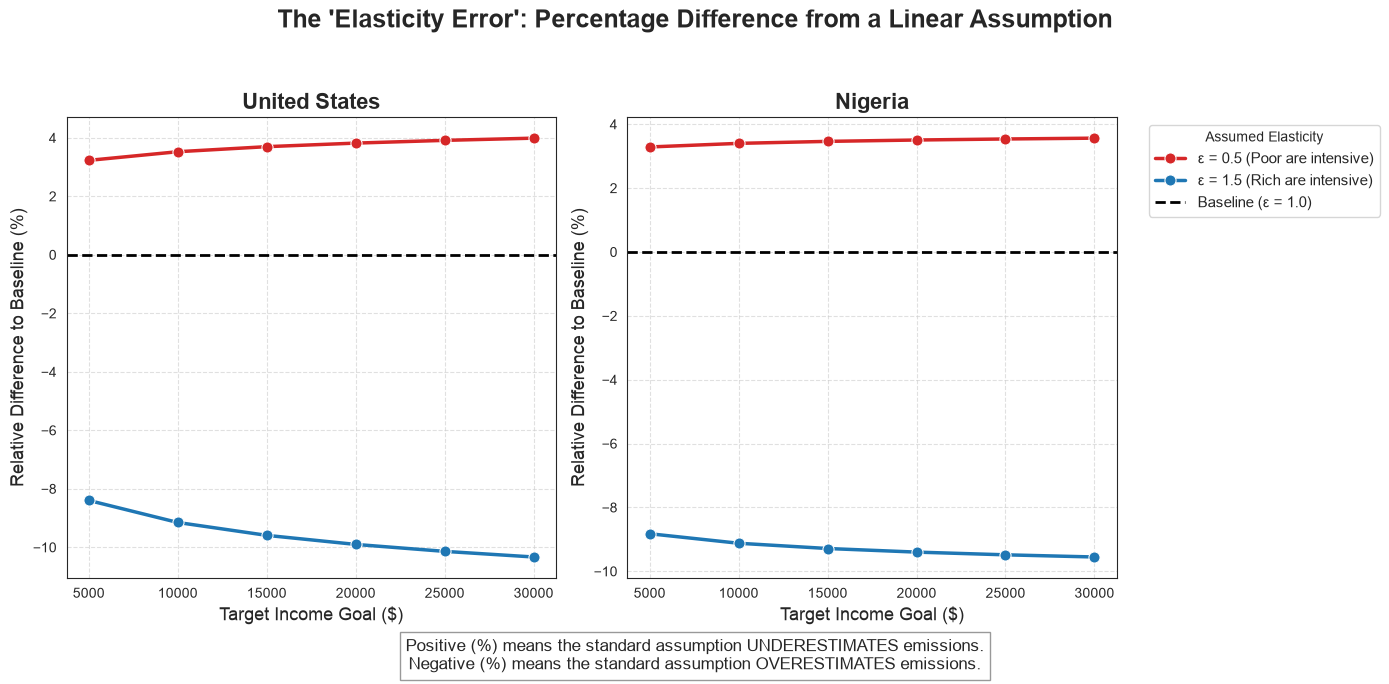

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load Data 
# ==========================================
try:
    df = pd.read_parquet("scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("scenario_results_with_deciles.csv")

# ==========================================
# 2. Filter & Prepare the Data
# ==========================================
target_fir = -0.05
target_cdr = "off"
target_countries = ["United States", "Nigeria"]

# 1. Isolate the macro data
df_macro = df[
    (df["Country"].isin(target_countries)) & 
    (df["Final_Improvement_Rate"] == target_fir) & 
    (df["CDR_Assumption"] == target_cdr)
][['Country', 'Year', 'Income_Goal', 'Elasticity', 'Macro_Total_Emissions']].drop_duplicates()

# 2. Calculate Cumulative Pathway Emissions
df_cumulative = df_macro.groupby(
    ['Country', 'Income_Goal', 'Elasticity']
)['Macro_Total_Emissions'].sum().reset_index()

# 3. Pivot the data so Elasticities become columns (easier to do math across rows)
df_pivot = df_cumulative.pivot(
    index=['Country', 'Income_Goal'], 
    columns='Elasticity', 
    values='Macro_Total_Emissions'
).reset_index()

# 4. Calculate Relative Differences (%) compared to the baseline (1.0)
df_pivot['Rel_Diff_0.5'] = ((df_pivot[0.5] - df_pivot[1.0]) / df_pivot[1.0]) * 100
df_pivot['Rel_Diff_1.5'] = ((df_pivot[1.5] - df_pivot[1.0]) / df_pivot[1.0]) * 100

# 5. Melt back to long format for Seaborn plotting
df_melted = df_pivot.melt(
    id_vars=['Country', 'Income_Goal'], 
    value_vars=['Rel_Diff_0.5', 'Rel_Diff_1.5'],
    var_name='Elasticity_Scenario', 
    value_name='Relative_Difference_Pct'
)

# Rename the variables so the legend looks clean
df_melted['Elasticity_Scenario'] = df_melted['Elasticity_Scenario'].replace({
    'Rel_Diff_0.5': 'ε = 0.5 (Poor are intensive)',
    'Rel_Diff_1.5': 'ε = 1.5 (Rich are intensive)'
})

# ==========================================
# 3. Create the Side-by-Side Plot
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False) # Keep sharey=False to see the curve shapes perfectly

for idx, country in enumerate(target_countries):
    ax = axes[idx]
    country_data = df_melted[df_melted["Country"] == country]
    
    sns.lineplot(
        data=country_data, 
        x="Income_Goal", 
        y="Relative_Difference_Pct", 
        hue="Elasticity_Scenario", 
        palette={"ε = 0.5 (Poor are intensive)": "#d62728", "ε = 1.5 (Rich are intensive)": "#1f77b4"}, 
        marker="o", 
        markersize=8,
        linewidth=2.5, 
        ax=ax
    )
    
    # Add a bold dashed baseline at 0%
    ax.axhline(0, color='black', linestyle='--', linewidth=2, label="Baseline (ε = 1.0)", zorder=1)
    
    ax.set_title(f"{country}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Target Income Goal ($)", fontsize=13)
    ax.set_ylabel("Relative Difference to Baseline (%)", fontsize=13)
    ax.grid(True, linestyle="--", alpha=0.6)
    
    # Format the legend beautifully
    if idx == 1:
        ax.legend(title="Assumed Elasticity", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    else:
        ax.get_legend().remove()

plt.suptitle("The 'Elasticity Error': Percentage Difference from a Linear Assumption", fontsize=18, fontweight='bold', y=1.05)

plt.figtext(0.5, -0.05, 
            "Positive (%) means the standard assumption UNDERESTIMATES emissions.\n"
            "Negative (%) means the standard assumption OVERESTIMATES emissions.", 
            ha="center", fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()